In [1]:
# !pip install boruta pycaret scikit-learn imbalanced-learn -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from boruta import BorutaPy
from sklearn.preprocessing import MinMaxScaler
import io
from contextlib import redirect_stdout

In [3]:
data = pd.read_csv(r"../../data/processed/data_vif.csv")

data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values("Date").reset_index(drop=True)

data = data.drop(columns=["return_t1(%)"], errors="ignore")

### One-Hot Encoding / Train분리

In [4]:
# Label을 0/1로 변환 (Low risk=0, High risk=1)
label_norm = data['Risk_Label'].astype(str).str.strip().str.lower()
label_map = {'low risk': 0, 'high risk': 1}
data['Risk_Label'] = label_norm.map(label_map)

data['Risk_Label'] = data['Risk_Label'].astype(int)

# train:valid:test 45:35:20
data_train = data[:int(len(data) * 0.45)]

# X, y 분리
X_train = data_train.drop(['Risk_Label', 'Date'], axis=1)  # 설명변수, Date는 ML에서 불필요
y_train = data_train['Risk_Label']  # 반응변수

### 보루타 파라미터 최적화(Confirmed 변수에 대해서만 진행)

In [5]:
# =========================
# Boruta parameter search - H1 기준
# =========================

import warnings
import io
from contextlib import redirect_stdout

import numpy as np
import pandas as pd

from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    f1_score,
    recall_score,
    precision_score
)

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module="sklearn.utils.parallel"
)

# -------------------------
# 1. Chronological split
# -------------------------
n = len(data)
train_end = int(n * 0.45)
valid_end = int(n * 0.80)

data_train = data.iloc[:train_end].copy()
data_valid = data.iloc[train_end:valid_end].copy()
data_test  = data.iloc[valid_end:].copy()

drop_cols = ["Risk_Label"]
if "Date" in data.columns:
    drop_cols.append("Date")

X_train = data_train.drop(columns=drop_cols)
y_train = data_train["Risk_Label"].astype(int)

X_valid = data_valid.drop(columns=drop_cols)
y_valid = data_valid["Risk_Label"].astype(int)

# -------------------------
# 2. Metric function
# -------------------------
def calc_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    gmean = np.sqrt(recall * specificity)

    h1 = (
        2 * f1 * gmean / (f1 + gmean)
        if (f1 + gmean) > 0
        else 0
    )

    return {
        "valid_accuracy": accuracy,
        "valid_f1": f1,
        "valid_recall": recall,
        "valid_precision": precision,
        "valid_specificity": specificity,
        "valid_gmean": gmean,
        "valid_h1": h1,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

# -------------------------
# 3. Search space
# -------------------------
perc_grid = [100, 95, 90]
max_depth_grid = [5, 6, 7]

base_rf_params = {
    "n_estimators": 500,
    "min_samples_leaf": 5,
    "min_samples_split": 2,
    "max_features": "sqrt",
    "class_weight": "balanced",
    "n_jobs": -1,
    "random_state": 1
}

boruta_search_history_h1 = []

# -------------------------
# 4. Boruta search
# -------------------------
for perc in perc_grid:
    for max_depth in max_depth_grid:

        print(f"\n[Searching] perc={perc}, max_depth={max_depth}")

        rf_for_boruta = RandomForestClassifier(
            **base_rf_params,
            max_depth=max_depth
        )

        selector = BorutaPy(
            estimator=rf_for_boruta,
            n_estimators=500,
            perc=perc,
            alpha=0.05,
            max_iter=100,
            random_state=1,
            verbose=0
        )

        # Boruta 출력 숨김
        with redirect_stdout(io.StringIO()):
            selector.fit(X_train.values, y_train.values)

        # Confirmed 변수만 사용
        selected_features = X_train.columns[selector.support_].tolist()

        if len(selected_features) == 0:
            row = {
                "perc": perc,
                "max_depth": max_depth,
                "n_selected": 0,
                "selected_features": [],
                "valid_accuracy": 0,
                "valid_f1": 0,
                "valid_recall": 0,
                "valid_precision": 0,
                "valid_specificity": 0,
                "valid_gmean": 0,
                "valid_h1": 0,
                "tn": 0,
                "fp": 0,
                "fn": 0,
                "tp": 0
            }
            boruta_search_history_h1.append(row)
            continue

        # 선택된 변수로 validation 성능 확인
        rf_eval = RandomForestClassifier(
            **base_rf_params,
            max_depth=max_depth
        )

        rf_eval.fit(X_train[selected_features], y_train)
        valid_pred = rf_eval.predict(X_valid[selected_features])

        metrics = calc_metrics(y_valid, valid_pred)

        row = {
            "perc": perc,
            "max_depth": max_depth,
            "n_selected": len(selected_features),
            "selected_features": selected_features,
            **metrics
        }

        boruta_search_history_h1.append(row)

# -------------------------
# 5. Result table
# -------------------------
boruta_search_df_h1 = pd.DataFrame(boruta_search_history_h1)

# H1 기준으로 Boruta 파라미터 선택
boruta_search_df_h1 = boruta_search_df_h1.sort_values(
    by=["valid_h1", "valid_gmean", "valid_f1", "valid_recall", "n_selected"],
    ascending=[False, False, False, False, True]
).reset_index(drop=True)

display(boruta_search_df_h1[
    [
        "perc", "max_depth", "n_selected",
        "valid_h1", "valid_gmean", "valid_f1",
        "valid_recall", "valid_precision", "valid_specificity",
        "tn", "fp", "fn", "tp"
    ]
])

best_boruta_h1 = boruta_search_df_h1.iloc[0]

best_boruta_params_h1 = {
    "perc": int(best_boruta_h1["perc"]),
    "max_depth": int(best_boruta_h1["max_depth"])
}

best_boruta_features_h1 = best_boruta_h1["selected_features"]

print("\n[Best Boruta Params - H1 기준]")
print(best_boruta_params_h1)

print("\n[Selected Features - H1 기준]")
print(best_boruta_features_h1)
print(f"\n선택 변수 개수: {len(best_boruta_features_h1)}")


[Searching] perc=100, max_depth=5

[Searching] perc=100, max_depth=6

[Searching] perc=100, max_depth=7

[Searching] perc=95, max_depth=5

[Searching] perc=95, max_depth=6

[Searching] perc=95, max_depth=7

[Searching] perc=90, max_depth=5

[Searching] perc=90, max_depth=6

[Searching] perc=90, max_depth=7


,perc,max_depth,n_selected,valid_h1,valid_gmean,valid_f1,valid_recall,valid_precision,valid_specificity,tn,fp,fn,tp
0,100,5,9,0.449945,0.627857,0.350598,0.483516,0.275000,0.815287,1024,232,94,88
1,90,5,12,0.445514,0.620068,0.347648,0.467033,0.276873,0.823248,1034,222,97,85
2,95,6,9,0.445345,0.615980,0.348739,0.456044,0.282313,0.832006,1045,211,99,83
3,95,5,10,0.438179,0.618556,0.339250,0.472527,0.264615,0.809713,1017,239,96,86
4,90,6,10,0.431627,0.592782,0.339367,0.412088,0.288462,0.852707,1071,185,107,75
5,95,7,9,0.427528,0.588817,0.335601,0.406593,0.285714,0.852707,1071,185,108,74
6,90,7,9,0.427528,0.588817,0.335601,0.406593,0.285714,0.852707,1071,185,108,74
7,100,6,8,0.419525,0.589997,0.325482,0.417582,0.266667,0.833599,1047,209,106,76
8,100,7,8,0.419095,0.575881,0.329412,0.384615,0.288066,0.862261,1083,173,112,70



[Best Boruta Params - H1 기준]
{'perc': 100, 'max_depth': 5}

[Selected Features - H1 기준]
['NASDAQ_return(%)', 'Brent Crude Oil_return(%)', 'KOSPI 200 Volume', 'VKOSPI_Close', 'KOSPI 200_RSI14', 'KOSPI 200_DMI14', 'KOSPI 200_PPO_Hist', 'KOSPI 200_OG', 'GJR_VaR_5_t1']

선택 변수 개수: 9


### 선택된 파라미터 기준으로 재실행(H1 기준)

In [6]:
# =========================
# Final Boruta selector 재실행
# 기준: H1
# =========================

final_perc = best_boruta_params_h1["perc"]
final_max_depth = best_boruta_params_h1["max_depth"]

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=final_max_depth,
    min_samples_leaf=5,
    min_samples_split=2,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=1
)

selector = BorutaPy(
    estimator=rf,
    n_estimators=500,
    perc=final_perc,
    alpha=0.05,
    max_iter=100,
    random_state=1,
    verbose=2
)

boruta_result = selector.fit(X_train.values, y_train.values)

result = boruta_result
selected_features = X_train.columns[selector.support_].tolist()

print("[Final Boruta Params - H1 기준]")
print({"perc": final_perc, "max_depth": final_max_depth})

print("\n[Confirmed Features]")
print(selected_features)
print(f"\n선택 변수 개수: {len(selected_features)}")

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	28
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	28
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	28
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	28
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	28
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	28
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	28
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	9
Tentative: 	3
Rejected: 	16
Iteration: 	9 / 100
Confirmed: 	9
Tentative: 	3
Rejected: 	16
Iteration: 	10 / 100
Confirmed: 	9
Tentative: 	3
Rejected: 	16
Iteration: 	11 / 100
Confirmed: 	9
Tentative: 	3
Rejected: 	16
Iteration: 	12 / 100
Confirmed: 	9
Tentative: 	3
Rejected: 	16
Iteration: 	13 / 100
Confirmed: 	9
Tentative: 	3
Rejected: 	16
Iteration: 	14 / 100
Confirmed: 	9
Tentative: 	3
Rejected: 	16
Iteration: 	15 / 100
Confirmed: 	9
Tentative: 	3
Rejected: 	16
Iteration: 	16 / 100
Confirmed: 	9
Tentative: 	2
Rejected: 	17
I

In [7]:
# 변수 중요도 퍼센트 테이블

def build_importance_pct_table(selector):
    feature_names = X_train.columns
    n_features = len(feature_names)

    imp_history = np.array(selector.importance_history_)
    if imp_history.ndim == 1:
        imp_history = imp_history.reshape(1, -1)

    # 실제 feature 구간만 사용
    imp_real = imp_history[:, :n_features].astype(float)

    # 중요도를 퍼센트로 정규화
    imp_real[imp_real == 0] = np.nan
    row_sums = np.nansum(imp_real, axis=1, keepdims=True)
    row_sums[row_sums == 0] = np.nan
    imp_pct = 100 * imp_real / row_sums

    # 경고 없는 평균 계산 (all-NaN 열은 0으로 처리)
    valid_counts = np.sum(np.isfinite(imp_pct), axis=0)
    sum_vals = np.nansum(imp_pct, axis=0)
    mean_pct = np.divide(
        sum_vals,
        valid_counts,
        out=np.zeros(n_features, dtype=float),
        where=valid_counts > 0
    )

    table = pd.DataFrame({
        'feature': feature_names,
        'Importance_pct': mean_pct,
        'status': 'Rejected'
    })
    table.loc[selector.support_, 'status'] = 'Confirmed'
    table.loc[selector.support_weak_, 'status'] = 'Tentative'

    return table.sort_values('Importance_pct', ascending=False).reset_index(drop=True)


table_result = build_importance_pct_table(result)

print('balanced 변수 중요도(%)')
display(table_result)

balanced 변수 중요도(%)


,feature,Importance_pct,status
0,NASDAQ_return(%),36.201994,Confirmed
1,Brent Crude Oil_return(%),9.700167,Confirmed
2,VKOSPI_Close,9.537674,Confirmed
3,KOSPI 200_DMI14,6.446768,Confirmed
4,GJR_VaR_5_t1,6.414385,Confirmed
5,KOSPI 200_PPO_Hist,6.375424,Confirmed
6,KOSPI 200 Volume,6.025914,Confirmed
7,KOSPI 200_OG,5.806789,Confirmed
8,KOSPI 200_RSI14,5.346259,Confirmed
9,KOSPI 200 lagged_1_return(%),4.598039,Rejected


### 모든 변수

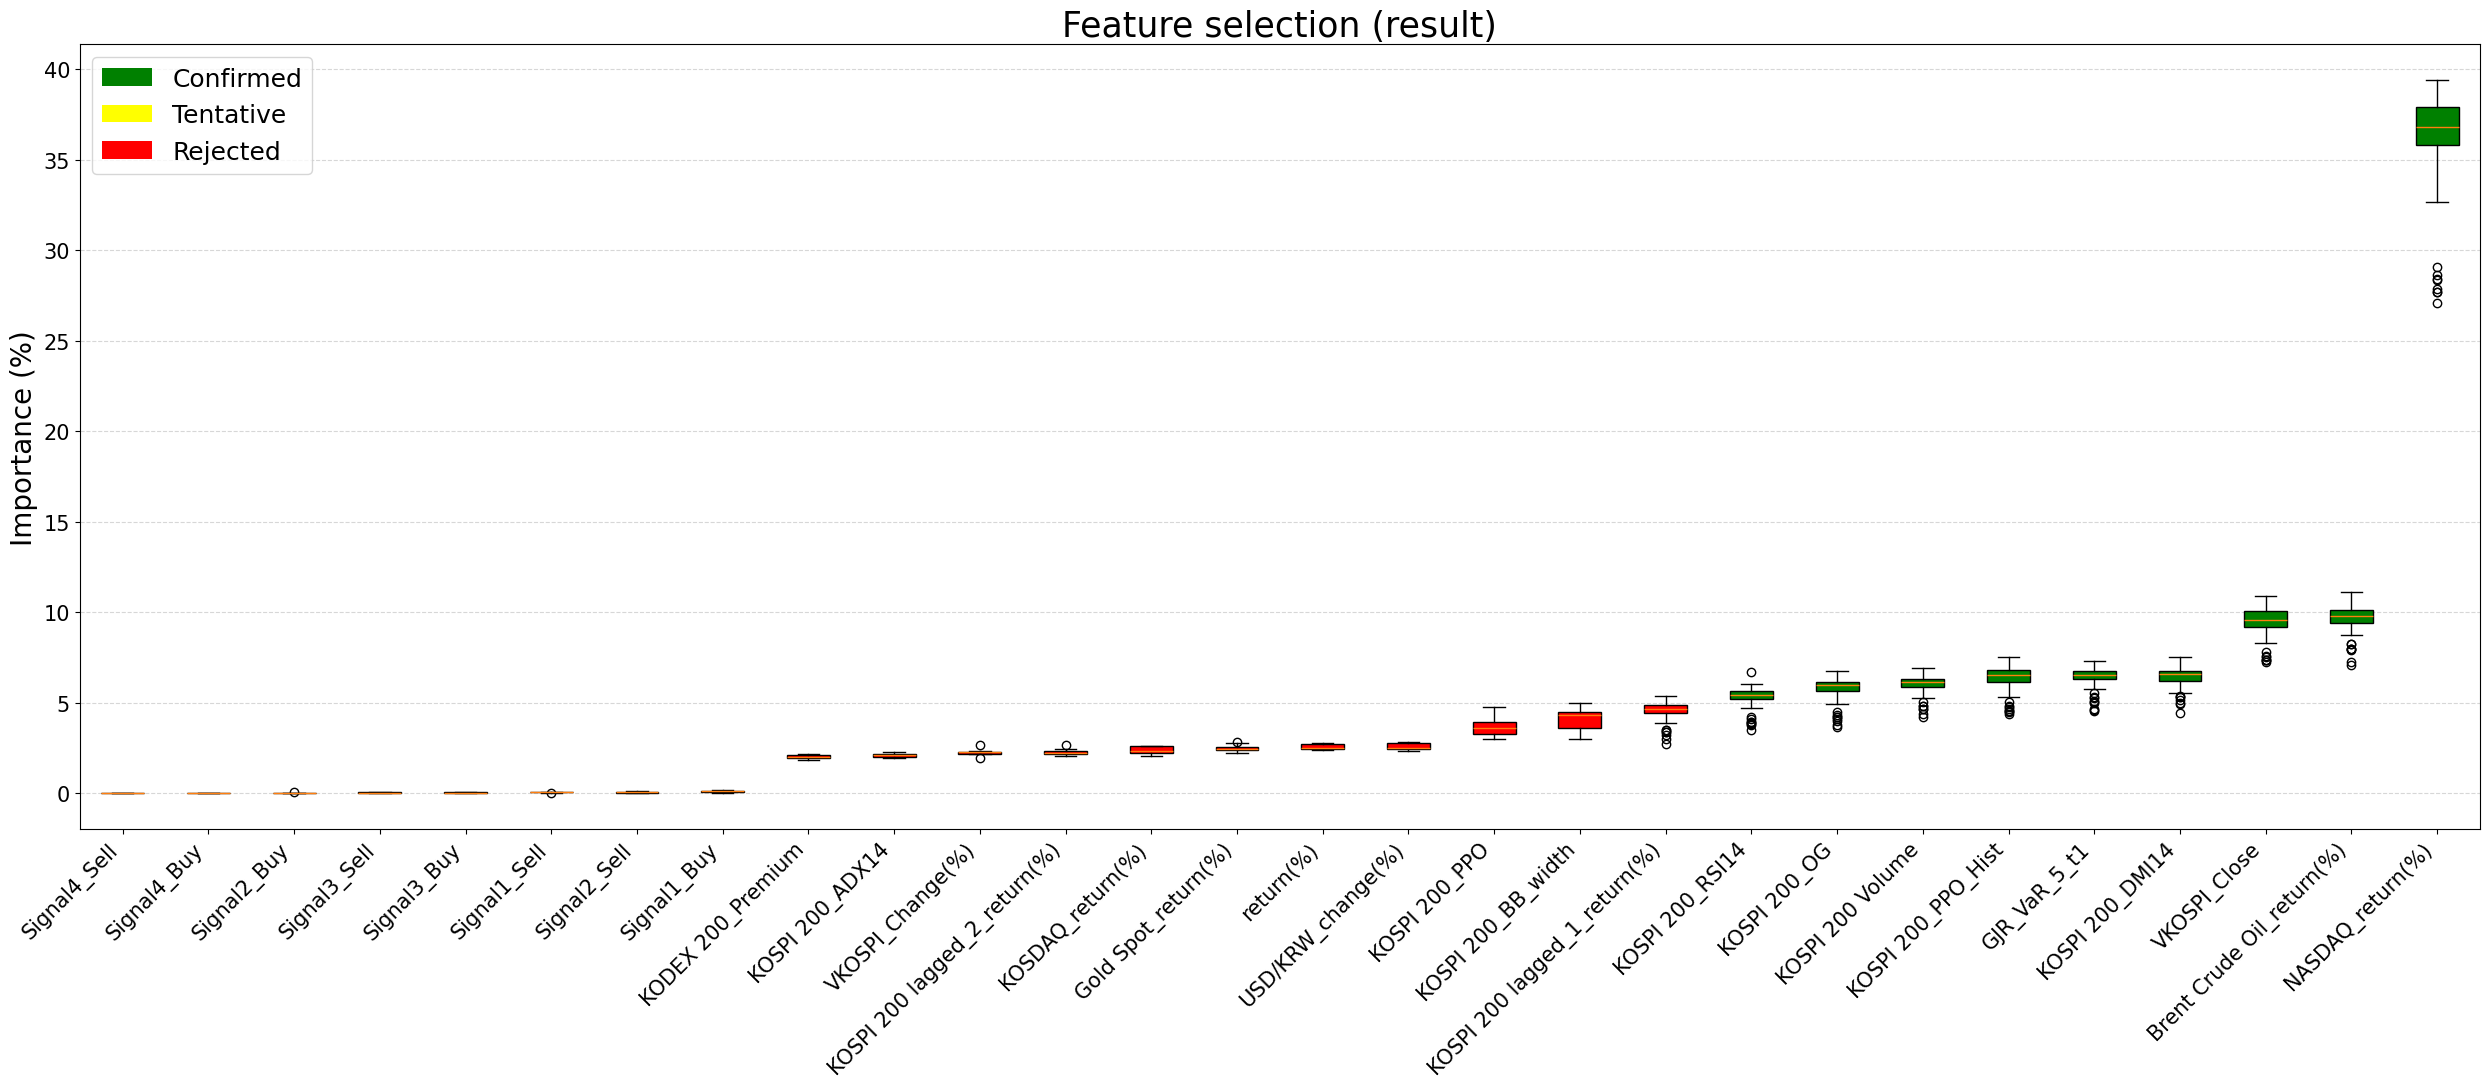

In [8]:
def plot_boruta_result(selector, plot_title):
    feature_names = X_train.columns
    n_features = len(feature_names)

    # Boruta importance history 가져오기
    imp_history = np.array(selector.importance_history_)
    if imp_history.ndim == 1:
        imp_history = imp_history.reshape(1, -1)

    imp_real = imp_history[:, :n_features].astype(float)
    imp_real[imp_real == 0] = np.nan

    # 퍼센트 변환 (분모 0 행은 NaN 유지)
    row_sums = np.nansum(imp_real, axis=1, keepdims=True)
    row_sums[row_sums == 0] = np.nan
    imp_pct_local = 100 * imp_real / row_sums

    # 전부 NaN이면 raw importance로 폴백
    use_fallback_raw = np.isnan(imp_pct_local).all()
    plot_values = imp_real if use_fallback_raw else imp_pct_local
    y_label = 'Importance (Z-score)' if use_fallback_raw else 'Importance (%)'

    # 경고 없는 평균 importance 계산 (all-NaN 컬럼은 0)
    valid_counts = np.sum(np.isfinite(plot_values), axis=0)
    sum_vals = np.nansum(plot_values, axis=0)
    mean_imp = np.divide(
        sum_vals,
        valid_counts,
        out=np.zeros(n_features, dtype=float),
        where=valid_counts > 0
    )

    # DataFrame 생성 및 정렬
    feat_df_local = pd.DataFrame({
        'feature': feature_names,
        'mean_importance': mean_imp,
        'status': ['Rejected'] * n_features
    })

    feat_df_local.loc[selector.support_, 'status'] = 'Confirmed'
    feat_df_local.loc[selector.support_weak_, 'status'] = 'Tentative'
    feat_df_local = feat_df_local.sort_values(by='mean_importance', ascending=True)

    # Boxplot 데이터 준비
    sorted_features = feat_df_local['feature'].tolist()
    sorted_status = feat_df_local['status'].tolist()
    sorted_idx = [list(feature_names).index(f) for f in sorted_features]
    values_sorted = plot_values[:, sorted_idx]

    box_data = []
    valid_features = []
    valid_status = []
    for i, feat in enumerate(sorted_features):
        vals = values_sorted[:, i]
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            continue
        box_data.append(vals)
        valid_features.append(feat)
        valid_status.append(sorted_status[i])

    # 색상 설정
    color_map = {'Confirmed': 'green', 'Tentative': 'yellow', 'Rejected': 'red'}
    box_colors = [color_map[s] for s in valid_status]

    plt.figure(figsize=(25, 11))
    bp = plt.boxplot(box_data, patch_artist=True)
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)

    plt.xticks(range(1, len(valid_features) + 1), valid_features, rotation=45, ha='right', fontsize=15)
    plt.ylabel(y_label, fontsize=20)
    plt.yticks(fontsize=15)
    plt.title(plot_title, fontsize=25)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    legend_elements = [
        Patch(facecolor='green', label='Confirmed'),
        Patch(facecolor='yellow', label='Tentative'),
        Patch(facecolor='red', label='Rejected')
    ]
    plt.legend(handles=legend_elements, loc='upper left', fontsize=18)
    plt.tight_layout()
    plt.show()

    return feat_df_local, plot_values


feat_df_result, imp_pct_result = plot_boruta_result(result, 'Feature selection (result)')

In [9]:
selected_features = feat_df_result[feat_df_result['status'] == 'Confirmed']['feature'].tolist()

# Confirmed와 Tentative 모두 선택하는 코드, 필요 시 사용
# selected_features = feat_df_result[feat_df_result['status'] != 'Rejected']['feature'].tolist()


data_selected = data[selected_features].copy()
data_selected['Date'] = pd.to_datetime(data['Date'])
data_selected['Risk_Label'] = data['Risk_Label']
data_selected.set_index('Date', inplace=True)
data_selected.head()

,KOSPI 200_RSI14,KOSPI 200_OG,KOSPI 200 Volume,KOSPI 200_PPO_Hist,GJR_VaR_5_t1,KOSPI 200_DMI14,VKOSPI_Close,Brent Crude Oil_return(%),NASDAQ_return(%),Risk_Label
Date,,,,,,,,,,
2009-04-17,63.873746,1.339314,251600000.0,0.132689,-2.736404,14.647201,35.49,0.0,0.157320,0
2009-04-20,76.439644,0.712077,183300000.0,0.056162,-2.640948,12.666581,36.15,0.0,-3.953850,0
2009-04-21,74.958299,-2.159026,204200000.0,-0.040207,-2.553087,9.561273,36.40,0.0,2.191930,0
2009-04-22,74.084326,0.767616,291400000.0,-0.038741,-2.469280,13.493950,35.01,0.0,0.137996,0
2009-04-23,69.951956,0.848630,277400000.0,-0.003434,-2.386329,15.409494,33.39,0.0,0.369276,1


In [10]:
# Boruta에서 Confirmed로 선택된 feature를 리스트 형태로 추출
selected_features = feat_df_result.loc[
    feat_df_result['status'] == 'Confirmed',
    'feature'
].tolist()

print(selected_features)

['KOSPI 200_RSI14', 'KOSPI 200_OG', 'KOSPI 200 Volume', 'KOSPI 200_PPO_Hist', 'GJR_VaR_5_t1', 'KOSPI 200_DMI14', 'VKOSPI_Close', 'Brent Crude Oil_return(%)', 'NASDAQ_return(%)']
